# Урок 1.2. Функции потерь и лучшая константа

**Интерактивная версия:** `lessons/lesson_1_2/web/index.html`

После урока вы сможете:
- сравнить квадратичные, абсолютные, Хьюбера и квантильные потери;
- найти лучшую константу для каждой потери и объяснить её как равновесие сил;
- оценить чувствительность к выбросам и выбрать квантиль по несимметричной цене ошибок;
- вычислить псевдо-остатки $-\partial L/\partial F$ и стартовый логит для классификации.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np

from gbcourse import GBRegressor, datasets, get_loss, style
from gbcourse.metrics import mse
from gbcourse.plotting import plot_data, plot_loss_functions, plot_truth, use_course_style
from gbcourse.rng import Mulberry32

use_course_style()

## 1. Формы потерь и их градиентов

Слева — цена ошибки $L(r)$, справа — псевдо-остаток $-\partial L/\partial F$: чему будет учиться дерево.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


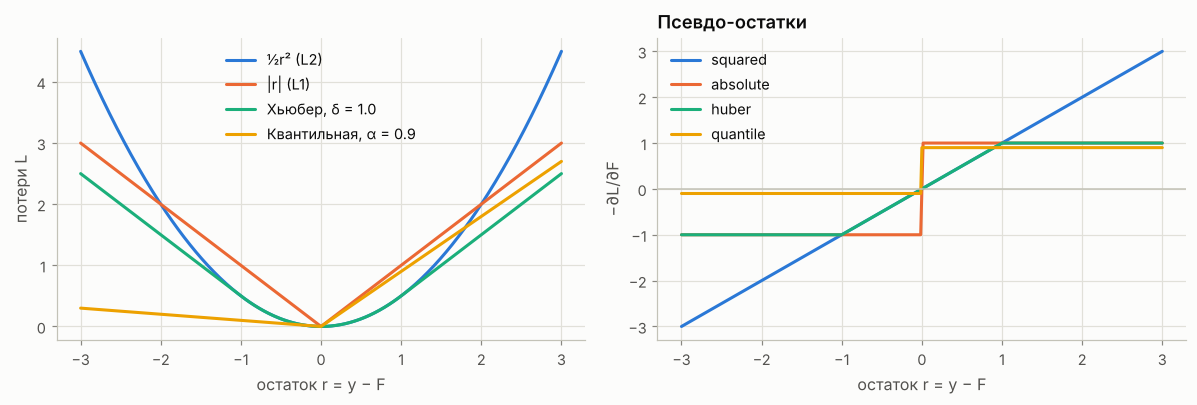

In [2]:
r = np.linspace(-3, 3, 401)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
plot_loss_functions(axes[0], names=("squared", "absolute", "huber", "quantile"), r_max=3, delta=1.0, alpha=0.9)
for (name, kw), color in zip([("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0}), ("quantile", {"alpha": 0.9})], style.SERIES):
    loss = get_loss(name, **kw)
    axes[1].plot(r, loss.negative_gradient(r, np.zeros_like(r)), color=color, label=name)
axes[1].axhline(0, color=style.AXIS, lw=1)
axes[1].set(xlabel="остаток r = y − F", ylabel="−∂L/∂F", title="Псевдо-остатки")
axes[1].legend()
fig.tight_layout()
plt.show()

## 2. Считаем руками: пять чисел

$y = (1, 2, 3, 4, 10)$. Сравним константы $c = 3$ (медиана) и $c = 4$ (среднее).

In [3]:
y = np.array([1, 2, 3, 4, 10.0])
for c in (3, 4, 5):
    rr = y - c
    print(f"c = {c}: Σ½r² = {np.sum(0.5 * rr**2):5.1f}   Σ|r| = {np.sum(np.abs(rr)):4.1f}")

c = 3: Σ½r² =  27.5   Σ|r| = 11.0
c = 4: Σ½r² =  25.0   Σ|r| = 12.0
c = 5: Σ½r² =  27.5   Σ|r| = 15.0


## 3. Лучшая константа — численно и формулой

Переберём $c$ на сетке и сравним с формулами. Для квантиля видна тонкость: точный минимизатор — наблюдение
с номером $\lceil \alpha n \rceil$, а `np.quantile` и `loss.init` интерполируют между соседями.

squared   численный минимум  4.000   loss.init = 4.000
absolute  численный минимум  3.000   loss.init = 3.000


huber     численный минимум  3.250   loss.init = 3.000


quantile  численный минимум 10.000   loss.init = 7.600


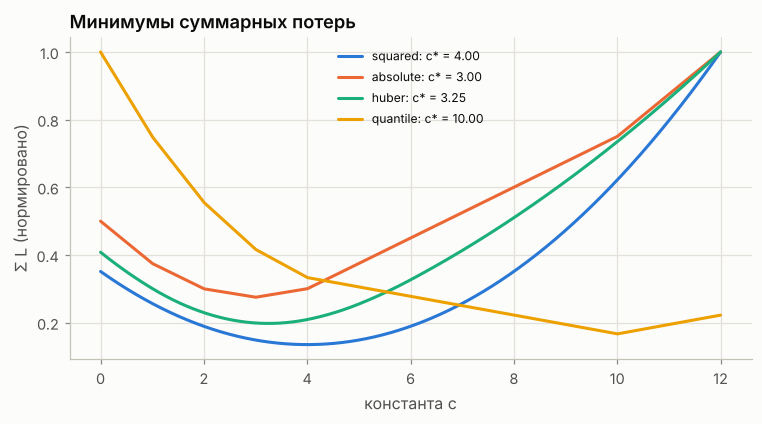

точная 0.9-квантиль: 10.0   np.quantile: 7.6000000000000005


In [4]:
cs = np.linspace(0, 12, 12001)
fig, ax = plt.subplots(figsize=(8, 3.8))
for (name, kw), color in zip([("squared", {}), ("absolute", {}), ("huber", {"delta": 3.0}), ("quantile", {"alpha": 0.9})], style.SERIES):
    loss = get_loss(name, **kw)
    total = np.array([loss.pointwise(y, np.full_like(y, c)).sum() for c in cs])
    c_star = cs[np.argmin(total)]
    ax.plot(cs, total / total.max(), color=color, label=f"{name}: c* = {c_star:.2f}")
    print(f"{name:9s} численный минимум {c_star:6.3f}   loss.init = {loss.init(y):.3f}")
ax.set(xlabel="константа c", ylabel="Σ L (нормировано)", title="Минимумы суммарных потерь")
ax.legend(fontsize=8)
plt.show()
print("точная 0.9-квантиль:", np.sort(y)[int(np.ceil(0.9 * len(y))) - 1], "  np.quantile:", np.quantile(y, 0.9))

## 4. Равновесие сил

В минимуме сумма антиградиентов $\sum_i -\partial L(y_i, c)/\partial c$ равна нулю. Проверим для гладких потерь.

In [5]:
for name, kw, c in [("squared", {}, y.mean()), ("huber", {"delta": 3.0}, 3.25)]:
    g = get_loss(name, **kw).negative_gradient(y, np.full_like(y, c))
    print(f"{name:8s} c = {c}: силы {g}, сумма {g.sum():+.2e}")

squared  c = 4.0: силы [-3. -2. -1. -0.  6.], сумма +0.00e+00
huber    c = 3.25: силы [-2.25 -1.25 -0.25  0.75  3.  ], сумма +0.00e+00


## 5. Выбросы: кривая чувствительности

Восемь обычных значений и одна подвижная точка $z$. Куда уходит лучшая константа?

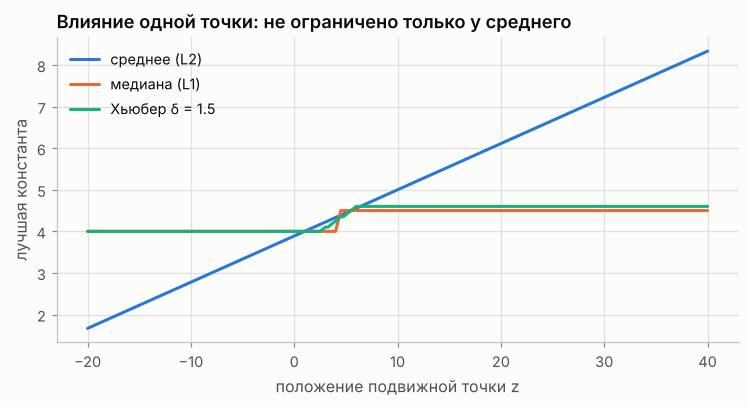

пятое число    10: среднее     4.0, медиана 3
пятое число   100: среднее    22.0, медиана 3
пятое число  1000: среднее   202.0, медиана 3


In [6]:
base = np.array([2, 3, 3.5, 4, 4.5, 5, 6, 7.0])
zs = np.linspace(-20, 40, 241)
huber = get_loss("huber", delta=1.5)
grid = np.linspace(-20, 40, 6001)


def huber_const(values: np.ndarray) -> float:
    return grid[np.argmin([huber.pointwise(values, np.full_like(values, c)).sum() for c in grid[::5]]) * 5]


curves = {"среднее (L2)": [], "медиана (L1)": [], "Хьюбер δ = 1.5": []}
for z in zs:
    v = np.append(base, z)
    curves["среднее (L2)"].append(v.mean())
    curves["медиана (L1)"].append(np.median(v))
    curves["Хьюбер δ = 1.5"].append(huber_const(v))
fig, ax = plt.subplots(figsize=(8, 3.6))
for (name, c), color in zip(curves.items(), style.SERIES):
    ax.plot(zs, c, color=color, label=name)
ax.set(xlabel="положение подвижной точки z", ylabel="лучшая константа", title="Влияние одной точки: не ограничено только у среднего")
ax.legend()
plt.show()

for big in (10, 100, 1000):
    v = np.array([1, 2, 3, 4, big], dtype=float)
    print(f"пятое число {big:5d}: среднее {v.mean():7.1f}, медиана {np.median(v):.0f}")

## 6. Несимметричная цена: сколько минут обещать

60 прошлых доставок. Минута опоздания в $k$ раз дороже минуты запаса — оптимальное обещание
равно $\frac{k}{k+1}$-квантили.

k =  1: α = 0.500, обещать 28.5 мин, опозданий 50%
k =  4: α = 0.800, обещать 33.6 мин, опозданий 20%
k =  9: α = 0.900, обещать 35.0 мин, опозданий 10%
k = 19: α = 0.950, обещать 36.4 мин, опозданий 5%


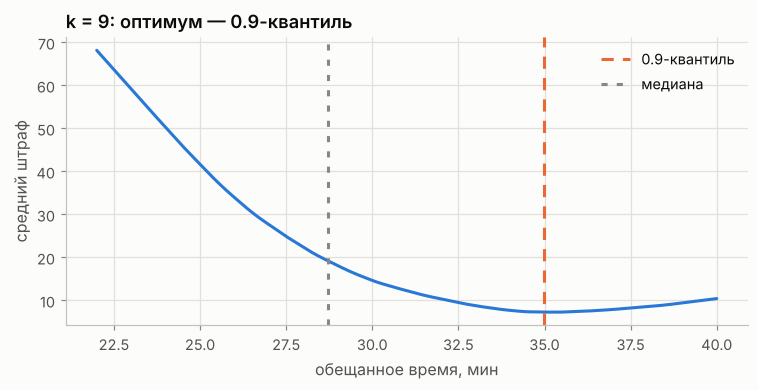

In [7]:
rng = Mulberry32(7)
times = np.array([22 + 6 * np.exp(0.55 * rng.normal()) for _ in range(60)])
for k in (1, 4, 9, 19):
    alpha = k / (k + 1)
    best = np.sort(times)[int(np.ceil(alpha * len(times))) - 1]
    print(f"k = {k:2d}: α = {alpha:.3f}, обещать {best:.1f} мин, опозданий {np.mean(times > best):.0%}")

k = 9
cost = lambda c: np.mean(np.where(times > c, k * (times - c), c - times))  # noqa: E731
cc = np.linspace(22, 40, 361)
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(cc, [cost(c) for c in cc], color=style.BLUE)
ax.axvline(np.sort(times)[53], color=style.ORANGE, ls=(0, (4, 3)), label="0.9-квантиль")
ax.axvline(np.median(times), color=style.MUTED, ls=(0, (2, 3)), label="медиана")
ax.set(xlabel="обещанное время, мин", ylabel="средний штраф", title="k = 9: оптимум — 0.9-квантиль")
ax.legend()
plt.show()

## 7. Псевдо-остатки и бустинг с разными потерями

Данные с двумя выбросами. Сравним, чему учится первое дерево, и как ведёт себя весь бустинг.

squared  F0 = +0.453, max |псевдо-остаток| = 6.61
absolute F0 = +0.196, max |псевдо-остаток| = 1.00
huber    F0 = +0.196, max |псевдо-остаток| = 1.00
squared  min_samples_leaf = 1: MSE на чистых данных 4.077


squared  min_samples_leaf = 5: MSE на чистых данных 1.160
absolute min_samples_leaf = 1: MSE на чистых данных 0.155
absolute min_samples_leaf = 5: MSE на чистых данных 0.150
huber    min_samples_leaf = 1: MSE на чистых данных 4.111


huber    min_samples_leaf = 5: MSE на чистых данных 0.170


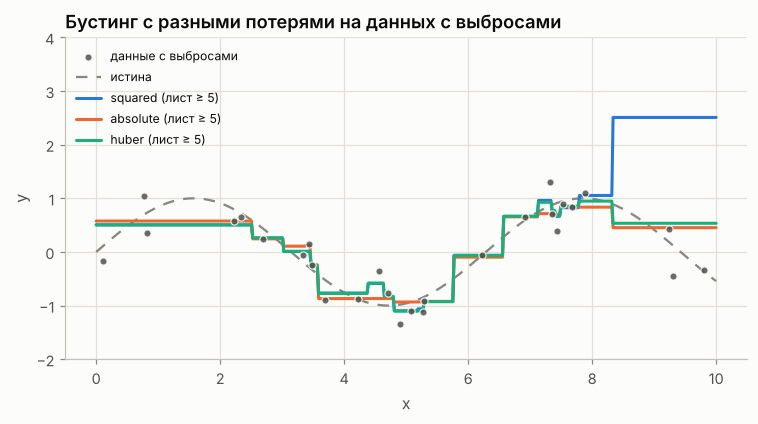

In [8]:
X, yo = datasets.regression_1d(kind="sine", n=30, noise=0.25, seed=4, outliers=0.1)
for name, kw in [("squared", {}), ("absolute", {}), ("huber", {"delta": 1.0})]:
    loss = get_loss(name, **kw)
    g = loss.negative_gradient(yo, np.full_like(yo, loss.init(yo)))
    print(f"{name:8s} F0 = {loss.init(yo):+.3f}, max |псевдо-остаток| = {np.abs(g).max():.2f}")

Xn, yn = datasets.regression_1d(kind="sine", n=300, noise=0.25, seed=104)
xs = np.linspace(0, 10, 500).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(8, 3.8))
plot_data(ax, X, yo, label="данные с выбросами")
plot_truth(ax, "sine", label="истина")
for (name, kw), color in zip([("squared", {}), ("absolute", {}), ("huber", {"huber_delta": 1.0})], style.SERIES):
    for msl in (1, 5):
        gb = GBRegressor(loss=name, n_estimators=100, learning_rate=0.1, max_depth=2, min_samples_leaf=msl, **kw).fit(X, yo)
        print(f"{name:8s} min_samples_leaf = {msl}: MSE на чистых данных {mse(yn, gb.predict(Xn)):.3f}")
    ax.plot(xs[:, 0], gb.predict(xs), color=color, lw=2, label=f"{name} (лист ≥ 5)")
ax.set(xlabel="x", ylabel="y", ylim=(-2, 4), title="Бустинг с разными потерями на данных с выбросами")
ax.legend(fontsize=8)
plt.show()

Хьюбер без ограничения на листья почти так же плох, как квадратичные потери: псевдо-остаток выброса обрезан,
но остаётся самым большим, дерево отрезает выброс в отдельный лист, а значение листа — лучшая константа для
одного объекта — равно всему его остатку. С `min_samples_leaf=5` выброс больше не получает свой лист.

## 8. Классификация: log-loss и стартовый логит

In [9]:
for p in (0.9, 0.5, 0.1, 0.01):
    print(f"y = 1, p = {p:4}: log-loss = {-np.log(p):.3f}")
labels = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
p_hat = labels.mean()
print("лучшая константа-вероятность:", p_hat, " стартовый логит:", np.log(p_hat / (1 - p_hat)))
print("gbcourse logistic init:", get_loss("logistic").init(labels))

y = 1, p =  0.9: log-loss = 0.105
y = 1, p =  0.5: log-loss = 0.693
y = 1, p =  0.1: log-loss = 2.303
y = 1, p = 0.01: log-loss = 4.605
лучшая константа-вероятность: 0.3  стартовый логит: -0.8472978603872036
gbcourse logistic init: -0.8472978603872036


## 9. Сверка с scikit-learn: стартовые константы бустинга

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

X5 = np.arange(5.0).reshape(-1, 1)
for loss in ("squared_error", "absolute_error", "huber"):
    gb = GradientBoostingRegressor(loss=loss, n_estimators=1).fit(X5, y)
    print(f"{loss:15s} F0 = {gb.init_.predict(X5)[0]:.3f}")
gq = GradientBoostingRegressor(loss="quantile", alpha=0.9, n_estimators=1).fit(X5, y)
print(f"{'quantile 0.9':15s} F0 = {gq.init_.predict(X5)[0]:.3f}")

squared_error   F0 = 4.000
absolute_error  F0 = 3.000
huber           F0 = 3.000
quantile 0.9    F0 = 7.600


## Упражнения

1. Для $y = \{1, 2, 3, 100\}$ постройте $\sum|y_i - c|$ на $[0, 5]$ и объясните плато на $[2, 3]$.
2. Найдите лучшую константу Хьюбера для $(1, 2, 3, 4, 10)$ при $\delta = 4$ руками и численно.
3. Для $y = \{2.1, \dots, 6.2, 11.5\}$ найдите оптимум Хьюбера при $\delta \in \{0.1, 0.5, 1, 3, 10\}$.
   К чему он стремится при $\delta \to 0$ и $\delta \to \infty$?
4. Булочная теряет 90 ₽ на непроданной булке и 10 ₽ на упущенном покупателе. Какую квантиль спроса печь?
5. Выведите псевдо-остатки потерь Хьюбера и проверьте их непрерывность.

<details><summary>Решения</summary>

`python lessons/lesson_1_2/exercises/solutions.py`
</details>